**GST FRAUD DETECTION SYSTEM**

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("GST_Fraud_Detection_Dataset_Final.csv")


df.head()

,GSTIN,Transaction_Amount,Tax_Amount,ITC_Claimed,Transaction_Frequency,Filing_Delay,Invoice_Mismatch,Return_Filing_Status,Business_Type,Previous_Fraud_History,Fraud_Label
0,1001,375446,67580.28,51979.65,18,1,No,Delayed,Service,No,0
1,1002,280040,50407.20,90684.54,38,8,Yes,Delayed,Wholesaler,Yes,1
2,1003,453242,81583.56,60289.33,8,1,No,Delayed,Wholesaler,No,0
3,1004,396446,71360.28,50388.25,28,2,Yes,Delayed,Manufacturer,No,0
4,1005,75428,13577.04,9702.59,16,0,No,On_Time,Manufacturer,No,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   GSTIN                   2000 non-null   int64  
 1   Transaction_Amount      2000 non-null   int64  
 2   Tax_Amount              2000 non-null   float64
 3   ITC_Claimed             2000 non-null   float64
 4   Transaction_Frequency   2000 non-null   int64  
 5   Filing_Delay            2000 non-null   int64  
 6   Invoice_Mismatch        2000 non-null   object 
 7   Return_Filing_Status    2000 non-null   object 
 8   Business_Type           2000 non-null   object 
 9   Previous_Fraud_History  2000 non-null   object 
 10  Fraud_Label             2000 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 172.0+ KB


In [ ]:
df.isnull().sum()

,0
GSTIN,0
Transaction_Amount,0
Tax_Amount,0
ITC_Claimed,0
Transaction_Frequency,0
Filing_Delay,0
Invoice_Mismatch,0
Return_Filing_Status,0
Business_Type,0
Previous_Fraud_History,0


In [ ]:
df['Fraud_Label'].value_counts()

,count
Fraud_Label,
0,1499
1,501


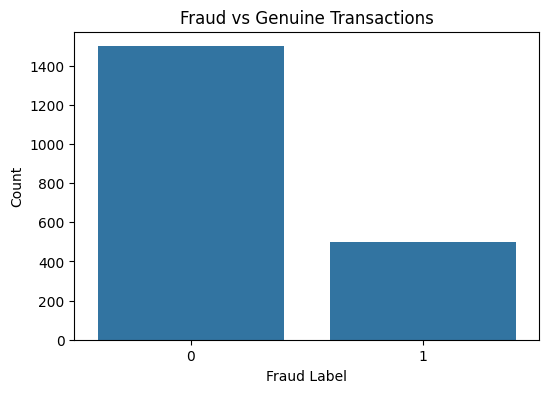

In [ ]:
# Fraud Distribution Graph

plt.figure(figsize=(6,4))

sns.countplot(x='Fraud_Label', data=df)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Count")

plt.show()

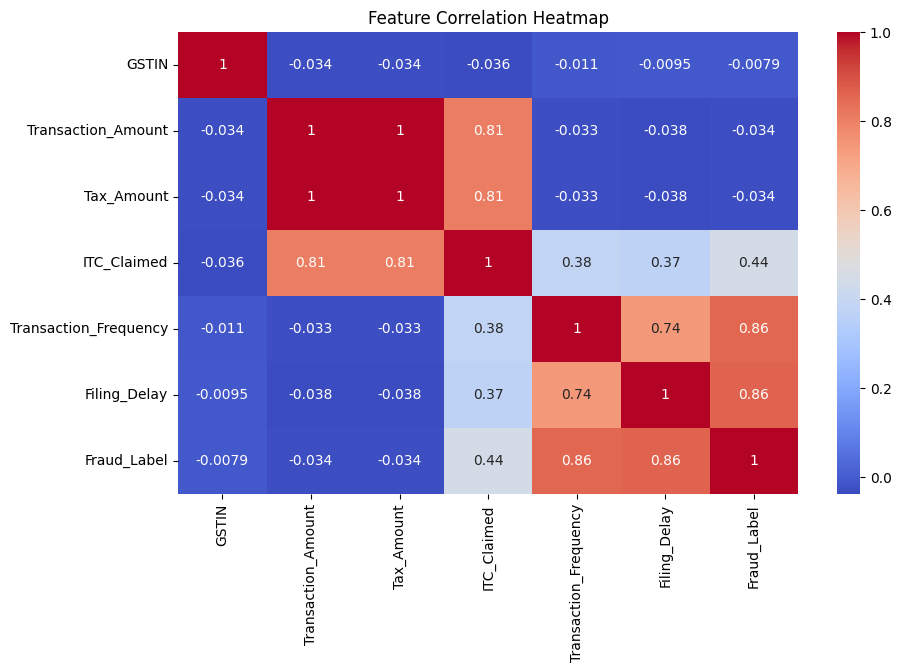

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
# Import ML Libraries

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Features and Target

X = df.drop(['Fraud_Label', 'GSTIN'], axis=1)

y = df['Fraud_Label']

# Convert Categorical Columns

X = pd.get_dummies(X)

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model

model = RandomForestClassifier()

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [ ]:
# Sample Prediction

sample = X_test.iloc[0:1]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Prediction: Fraudulent Transaction")
else:
    print("Prediction: Genuine Transaction")

Prediction: Fraudulent Transaction


TESTING ON NEW UNSEEN DATA

In [ ]:
# Create Sample New GST Records

new_data = pd.DataFrame({

    'Transaction_Amount': [85000, 12000, 95000],

    'Tax_Amount': [15300, 2160, 17100],

    'ITC_Claimed': [14500, 1800, 16500],

    'Transaction_Frequency': [25, 5, 30],

    'Filing_Delay': [18, 0, 22],

    'Invoice_Mismatch': ['Yes', 'No', 'Yes'],

    'Return_Filing_Status': ['Late', 'On Time', 'Late'],

    'Business_Type': ['Retail', 'Wholesale', 'Manufacturing'],

    'Previous_Fraud_History': ['Yes', 'No', 'Yes']

})

new_data

,Transaction_Amount,Tax_Amount,ITC_Claimed,Transaction_Frequency,Filing_Delay,Invoice_Mismatch,Return_Filing_Status,Business_Type,Previous_Fraud_History
0,85000,15300,14500,25,18,Yes,Late,Retail,Yes
1,12000,2160,1800,5,0,No,On Time,Wholesale,No
2,95000,17100,16500,30,22,Yes,Late,Manufacturing,Yes


In [ ]:
# Convert Categorical Data

new_data_encoded = pd.get_dummies(new_data)

# Align Columns with Training Data

new_data_encoded = new_data_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

new_data_encoded.head()

,Transaction_Amount,Tax_Amount,ITC_Claimed,Transaction_Frequency,Filing_Delay,Invoice_Mismatch_No,Invoice_Mismatch_Yes,Return_Filing_Status_Delayed,Return_Filing_Status_On_Time,Business_Type_Manufacturer,Business_Type_Retailer,Business_Type_Service,Business_Type_Wholesaler,Previous_Fraud_History_No,Previous_Fraud_History_Yes
0,85000,15300,14500,25,18,False,True,0,0,0,0,0,0,False,True
1,12000,2160,1800,5,0,True,False,0,0,0,0,0,0,True,False
2,95000,17100,16500,30,22,False,True,0,0,0,0,0,0,False,True


In [ ]:
# Predict Fraud

predictions = model.predict(new_data_encoded)

# Add Predictions to Original Data

new_data['Prediction'] = predictions

# Convert Labels into Text

new_data['Prediction'] = new_data['Prediction'].map({
    0: 'Genuine',
    1: 'Fraudulent'
})

# Display Results

new_data

,Transaction_Amount,Tax_Amount,ITC_Claimed,Transaction_Frequency,Filing_Delay,Invoice_Mismatch,Return_Filing_Status,Business_Type,Previous_Fraud_History,Prediction
0,85000,15300,14500,25,18,Yes,Late,Retail,Yes,Fraudulent
1,12000,2160,1800,5,0,No,On Time,Wholesale,No,Genuine
2,95000,17100,16500,30,22,Yes,Late,Manufacturing,Yes,Fraudulent
